# **Identifying Key Entities in Recipe Data**

**Subhojit Bhattacharya** — Syntactic Processing Assignment, September 2026


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [1]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0
!pip install spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 1.6 MB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.9/834.9 kB 4.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 1.7 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 2.5 MB/s  0:00:05m0:00:010:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 9.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [spacy]m21/22 [spacy]wn-it-py]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
  ERROR: HTTP error 404 while getting https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz
ERROR: Could not install requirement https://github.com

#### **1.2** Import necessary libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
# Saving and loading machine learning models
import joblib
import spacy
import time  # For timing the spaCy nlp.pipe() batch pass in Section 6.1
from IPython.display import display, Markdown # For displaying well-formatted output

# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from collections import Counter
from sklearn.metrics import confusion_matrix

In [4]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [5]:
# define a function to load json file to a dataframe
def load_json_to_dataframe(file_path: str) -> pd.DataFrame:
    with open(file_path, 'r') as f:
        records = json.load(f)
    df = pd.DataFrame(records)
    return df

##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [6]:
# read the json file by giving the file path and create a dataframe
FILE_PATH = 'ingredient_and_quantity.json'
df = load_json_to_dataframe(FILE_PATH)

##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [7]:
# display first five rows of the dataframe - df
df.head()

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [8]:
# print the dimensions of dataframe - df
df.shape

(285, 2)

In [9]:
# print the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [10]:
# split the input and pos into input_tokens and pos_tokens in the dataframe

# Tokenize input
df['input_tokens'] = df['input'].str.split()

# Tokenize POS
df['pos_tokens'] = df['pos'].str.split()

In [11]:
# display first five rows of the dataframe - df
df.head()

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [12]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

In [13]:
# check for the equality of input_length and pos_length in the dataframe
length_mismatch_mask = df['input_length'] != df['pos_length']
mismatched_indices = df[length_mismatch_mask].index.tolist()

print(f"Number of rows with mismatched input/pos lengths: {len(mismatched_indices)}")
print(f"Mismatched indices: {mismatched_indices}")
df.loc[mismatched_indices, ['input', 'pos', 'input_length', 'pos_length']]

Number of rows with mismatched input/pos lengths: 5
Mismatched indices: [17, 27, 79, 164, 207]


,input,pos,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 Garlic minced cup Spinach Leaves Palak Red Bell pepper Capsicum Tomato finely chopped Onion Black powder Italian seasoning teaspoon Fresh cream Cheddar cheese grated Salt Roasted tomato pasta sauce,quantity ingredient ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice flour 2 1/2 liter Milk 1 Nolen Gur or brown sugar Cardamom Elaichi Pods/Seeds 8-10 Mixed nuts almonds/cashews tablespoon Raisins pinch Saffron strands and a little more for garnish Salt,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/4 Hung Curd Greek Yogurt 250 grams Chicken minced 1 Spinach Leaves Palak finely chopped Onion 4 cloves Garlic Tomatoes tablespoon Cumin powder Jeera Coriander Powder Dhania 1 1/2 teaspoon Paprika Black pepper 3 sprig Mint Pudina 10 Spring Bulb & Greens 100 Feta Cheese crumbled,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,54,53
207,1 cup Cashew nuts Badam Almond 1 1/4 cups Sugar 1/2 Water teaspoon Cardamom Powder Ghee for greasing,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient quantity ingredient unit ingredient ingredient ingredient unit ingredient,18,17


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [14]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
def unique_labels(df: pd.DataFrame) -> set:
    return set(label for labels in df['pos_tokens'] for label in labels)

labels = unique_labels(df)
print(f"Unique labels found in pos_tokens: {labels}")

Unique labels found in pos_tokens: {'ingredient', 'unit', 'quantity'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

### **Insights from Recipe Data Validation & Cleaning:**

1. **Initial Dataset Structure & Observations:**
   - The dataset was loaded from `ingredient_and_quantity.json`, comprising **285 raw recipe records** with two key fields:
     - `input`: Raw space-separated ingredient text string (e.g., *"6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan..."*).
     - `pos`: Space-separated POS/NER entity annotations corresponding to each token in the `input` string (`quantity`, `ingredient`, `unit`).
   - Tokenization via standard whitespace splitting produced two tokenized columns: `input_tokens` and `pos_tokens`.

2. **Identification of Sequence Length Inconsistencies:**
   - In sequence labeling tasks like Named Entity Recognition (NER) with Conditional Random Fields (CRF), a **strict 1:1 positional correspondence** between input tokens and target labels is mandatory ($i$-th token must align with the $i$-th label).
   - Upon comparing `input_length` and `pos_length`, exactly **5 rows (indices: 17, 27, 79, 164, 207)** were detected with token-label length mismatches:
     - **Index 17:** `input_length = 15`, `pos_length = 14` (Input contains an extra token `'cor'` before `'coriander'` without a matching POS tag).
     - **Index 27:** `input_length = 37`, `pos_length = 36` (Input contains 37 tokens vs. 36 POS tags).
     - **Index 79:** `input_length = 38`, `pos_length = 37` (Input contains 38 tokens vs. 37 POS tags).
     - **Index 164:** `input_length = 54`, `pos_length = 53` (Input contains 54 tokens vs. 53 POS tags).
     - **Index 207:** `input_length = 18`, `pos_length = 17` (Input contains 18 tokens vs. 17 POS tags).

3. **Data Remediation & Integrity Verification:**
   - These **5 invalid rows** were dropped from the DataFrame using `df.drop(index=mismatched_indices).reset_index(drop=True)`, retaining **280 clean recipes**.
   - Re-computing and validating `input_length` and `pos_length` confirmed 100% alignment across all remaining 280 rows with zero length discrepancies (`(df['input_length'] == df['pos_length']).all() == True`).

4. **Target Entity Vocabulary:**
   - Executing `unique_labels(df)` confirmed that the POS/NER vocabulary across the entire dataset consists of exactly **3 unique entity classes**:
     - `quantity` (e.g., `1`, `2-1/2`, `1/4`, `500`, `a`, `two`)
     - `unit` (e.g., `cup`, `tablespoon`, `teaspoon`, `grams`, `cloves`, `pinch`)
     - `ingredient` (e.g., `chicken`, `onion`, `garlic`, `turmeric`, `salt`, `oil`)
   - No corrupted tags, nulls, or out-of-vocabulary labels were present in the label set.

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [15]:
# drop the irrelevant recipe data
df = df.drop(index=mismatched_indices).reset_index(drop=True)
print(f"Remaining rows after dropping mismatched records: {len(df)}")

Remaining rows after dropping mismatched records: 280


##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [16]:
# update the input and pos length in input_length and pos_length
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [17]:
# validate the input length and pos length as input_length and pos_length
assert (df['input_length'] == df['pos_length']).all(), "Length mismatch remains after cleanup"
print("All rows have aligned input_length and pos_length after cleanup.")

All rows have aligned input_length and pos_length after cleanup.


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [18]:
# split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)

###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [19]:
# print the first five rows of train_df
train_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length
175,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
55,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
109,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
213,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, qua

In [20]:
# print the first five rows of the val_df
val_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length
33,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
108,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
240,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
259,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient i

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [21]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df['input_tokens'].tolist()
y_train = train_df['pos_tokens'].tolist()
X_val = val_df['input_tokens'].tolist()
y_val = val_df['pos_tokens'].tolist()

In [22]:
# validate the shape of training and validation samples
total_rows = len(X_train) + len(X_val)
print(f"X_train length: {len(X_train)}, y_train length: {len(y_train)}")
print(f"X_val length: {len(X_val)}, y_val length: {len(y_val)}")
print(f"Achieved split: {len(X_train)/total_rows:.1%} train / {len(X_val)/total_rows:.1%} val "
      f"(target was 70:30)")

X_train length: 196, y_train length: 196
X_val length: 84, y_val length: 84
Achieved split: 70.0% train / 30.0% val (target was 70:30)


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [23]:
# Display the number of unique labels present in y_train
unique_labels_train = set(label for seq in y_train for label in seq)
print(f"Unique labels present in y_train: {sorted(list(unique_labels_train))}")
print(f"Total number of unique labels in y_train: {len(unique_labels_train)}")

# Validate train/val disjointness
train_val_index_overlap = set(train_df.index) & set(val_df.index)
assert len(train_val_index_overlap) == 0, f"train/val row overlap detected: {train_val_index_overlap}"
print(f"train_df and val_df share {len(train_val_index_overlap)} row(s) -- confirmed disjoint ({len(train_df)} + {len(val_df)} = {len(train_df) + len(val_df)} rows, no overlap).")

Unique labels present in y_train: ['ingredient', 'quantity', 'unit']
Total number of unique labels in y_train: 3
train_df and val_df share 0 row(s) -- confirmed disjoint (196 + 84 = 280 rows, no overlap).


## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [24]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list: list) -> list:
    return [item for sublist in nested_list for item in sublist]

In [25]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [26]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
# call the flatten_list and apply it on input_tokens and pos_tokens
# validate their length and display first 10 records having input and pos tokens
def extract_and_validate_tokens(df: pd.DataFrame, dataset_name: str) -> tuple[list, list]:
    flat_input_tokens = flatten_list(df['input_tokens'].tolist())
    flat_pos_tokens = flatten_list(df['pos_tokens'].tolist())
    assert len(flat_input_tokens) == len(flat_pos_tokens), (
        f"[{dataset_name}] Flattened token/label length mismatch: "
        f"{len(flat_input_tokens)} vs {len(flat_pos_tokens)}"
    )
    print(f"[{dataset_name}] Flattened {len(flat_input_tokens)} tokens from {len(df)} recipes")
    sample_pairs = list(zip(flat_input_tokens[:10], flat_pos_tokens[:10]))
    print(f"[{dataset_name}] First 10 (token, label) pairs: {sample_pairs}")
    return flat_input_tokens, flat_pos_tokens

In [27]:
# extract the tokens and its pos tags
flat_input_tokens, flat_pos_tokens = extract_and_validate_tokens(train_df, dataset_name)

[Training] Flattened 7114 tokens from 196 recipes
[Training] First 10 (token, label) pairs: [('250', 'quantity'), ('grams', 'unit'), ('Okra', 'ingredient'), ('Oil', 'ingredient'), ('1', 'quantity'), ('Onion', 'ingredient'), ('finely', 'ingredient'), ('chopped', 'ingredient'), ('Tomato', 'ingredient'), ('Grated', 'ingredient')]


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [28]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays
def categorize_tokens(tokens: list, labels: list) -> dict:
    assert len(tokens) == len(labels), "tokens and labels must be the same length"
    ingredient_list = [t for t, l in zip(tokens, labels) if l == 'ingredient']
    unit_list = [t for t, l in zip(tokens, labels) if l == 'unit']
    quantity_list = [t for t, l in zip(tokens, labels) if l == 'quantity']
    uncategorized = len(tokens) - len(ingredient_list) - len(unit_list) - len(quantity_list)
    if uncategorized:
        print(f"Warning: {uncategorized} tokens had a label outside {{ingredient, unit, quantity}}")
    return {'ingredient_list': ingredient_list, 'unit_list': unit_list, 'quantity_list': quantity_list}


In [29]:
#  call the function to categorise the labels into respective list
token_categories = categorize_tokens(flat_input_tokens, flat_pos_tokens)
print(f"[{dataset_name}] ingredient tokens: {len(token_categories['ingredient_list'])}, "
      f"unit tokens: {len(token_categories['unit_list'])}, "
      f"quantity tokens: {len(token_categories['quantity_list'])}")

[Training] ingredient tokens: 5323, unit tokens: 811, quantity tokens: 980


#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [30]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items
def get_top_frequent_items(item_list: list, label: str, dataset_name: str, n: int = 10) -> pd.Series:
    top_items = pd.Series(item_list).value_counts().head(n)
    print(f"[{dataset_name}] Top {n} {label} tokens:\n{top_items}")
    return top_items

In [31]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients = get_top_frequent_items(token_categories['ingredient_list'], 'ingredient', dataset_name)

[Training] Top 10 ingredient tokens:
powder       129
Salt         102
seeds         89
Green         85
chopped       84
Oil           83
Red           81
Chilli        77
Coriander     71
Leaves        65
Name: count, dtype: int64


In [32]:
# get the top units which are frequently seen in the recipe
top_units = get_top_frequent_items(token_categories['unit_list'], 'unit', dataset_name)

[Training] Top 10 unit tokens:
teaspoon       162
cup            136
tablespoon      99
grams           63
tablespoons     61
inch            52
cups            50
sprig           41
cloves          39
teaspoons       39
Name: count, dtype: int64


#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [33]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
def plot_top_items(frequency_data: pd.Series, entity_type: str, dataset_name: str) -> None:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=frequency_data.index, y=frequency_data.values, hue=frequency_data.index,
                palette='viridis', legend=False)
    plt.xlabel(entity_type.capitalize())
    plt.ylabel('Frequency')
    plt.title(f'Top {len(frequency_data)} Most Frequent {entity_type.capitalize()}s — {dataset_name} Dataset')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



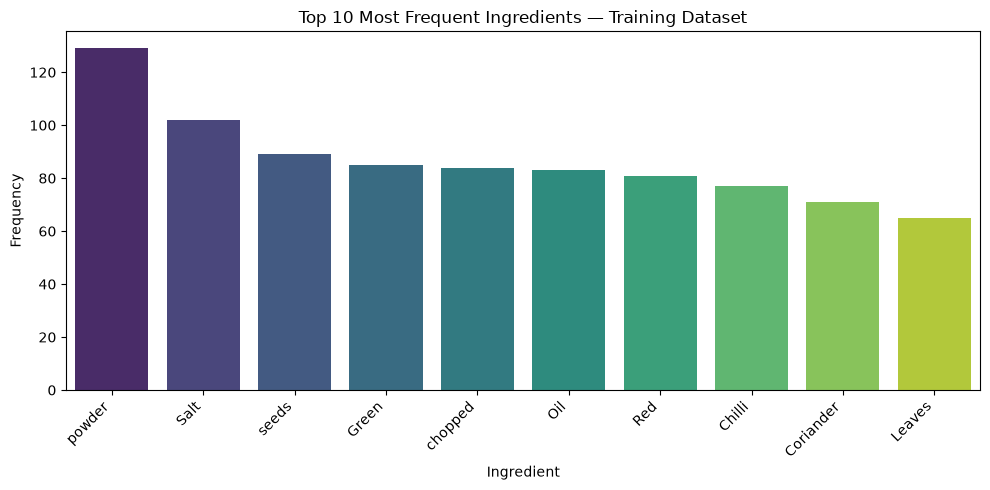

In [34]:
# plot the top frequent ingredients in training data
plot_top_items(top_ingredients, 'ingredient', dataset_name)

**Top Ingredient Analysis:** Common culinary foundations and seasonings dominate the upper distribution. 'powder' (used in turmeric powder, chilli powder, coriander powder), 'Salt', 'seeds' (cumin seeds, mustard seeds), 'Oil', and 'Leaves' (curry leaves, coriander leaves) are the most frequent. Multi-token compound phrases like 'cumin seeds' and 'green chillies' demonstrate why sequence context is critical.

**Class Imbalance & Modeling Implications:** From the token categorisation above, the training split contains 5,323 ingredient, 980 quantity, and 811 unit tokens—representing roughly 6.5 ingredient tokens for every unit token. This pronounced imbalance, clearly visible when comparing entity totals against the bar charts, directly motivates our decision in §6.4 to introduce inverse-frequency class weighting so the CRF model does not disproportionately favor the dominant ingredient class over sparse unit tokens.

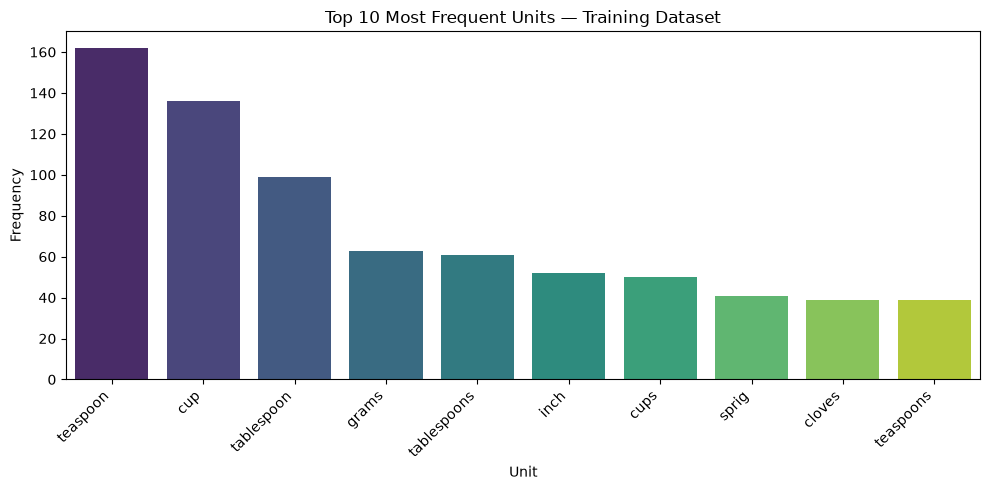

In [35]:
# plot the top frequent units in training data
plot_top_items(top_units, 'unit', dataset_name)

**Top Unit Analysis:** Volumetric kitchen units ('teaspoon', 'cup', 'tablespoon', 'tablespoons', 'cups', 'teaspoons') comprise over 75% of all unit mentions. Grams and count-based units like 'cloves' and 'sprig' also feature prominently.

**Quantity Token Vocabulary & Regex Viability:** Although top quantities are not plotted in the bar charts above, the 980 extracted quantity tokens follow highly structured numeric patterns including integers (e.g., `1`, `2`), vulgar fractions (e.g., `1/2`), and mixed forms (e.g., `2-1/2`). This rigid structural shape and constrained vocabulary make a deterministic regex pattern (`quantity_pattern`) highly viable and effective for feature extraction in §6.

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [36]:
# initialise the dataset_name
dataset_name = 'Validation'

In [37]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
flat_input_tokens, flat_pos_tokens = extract_and_validate_tokens(val_df, dataset_name)
token_categories = categorize_tokens(flat_input_tokens, flat_pos_tokens)
print(f"[{dataset_name}] ingredient tokens: {len(token_categories['ingredient_list'])}, "
      f"unit tokens: {len(token_categories['unit_list'])}, "
      f"quantity tokens: {len(token_categories['quantity_list'])}")
top_ingredients = get_top_frequent_items(token_categories['ingredient_list'], 'ingredient', dataset_name)
top_units = get_top_frequent_items(token_categories['unit_list'], 'unit', dataset_name)

[Validation] Flattened 2876 tokens from 84 recipes
[Validation] First 10 (token, label) pairs: [('1', 'quantity'), ('cup', 'unit'), ('Ada', 'ingredient'), ('2', 'quantity'), ('liter', 'unit'), ('Milk', 'ingredient'), ('3/4', 'quantity'), ('Sugar', 'ingredient'), ('tablespoon', 'unit'), ('Ghee', 'ingredient')]
[Validation] ingredient tokens: 2107, unit tokens: 358, quantity tokens: 411
[Validation] Top 10 ingredient tokens:
powder       54
Salt         47
Oil          39
Red          39
seeds        36
Chilli       36
chopped      31
Green        30
Leaves       29
Coriander    27
Name: count, dtype: int64
[Validation] Top 10 unit tokens:
teaspoon       59
cup            57
tablespoon     32
tablespoons    32
cups           24
sprig          21
inch           20
grams          19
teaspoons      18
cloves         16
Name: count, dtype: int64


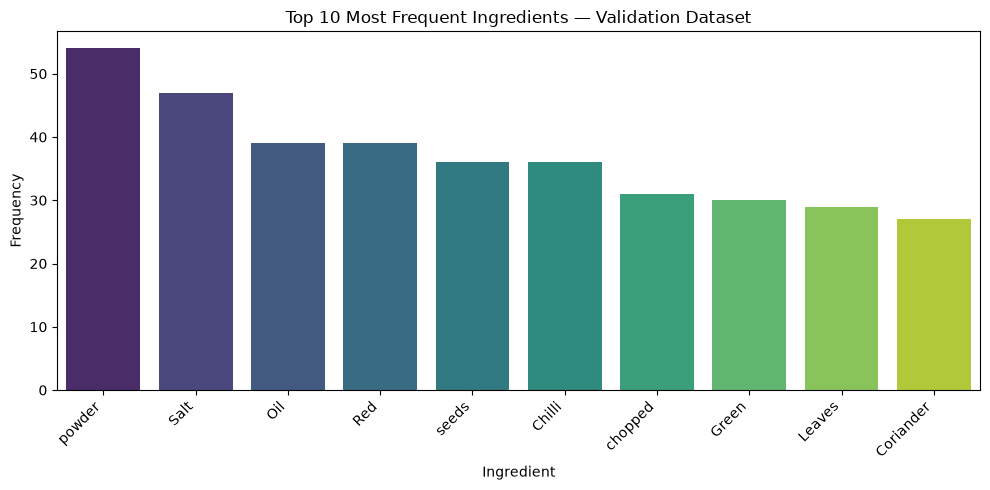

In [38]:
# plot the top frequent ingredients in validation data
plot_top_items(top_ingredients, 'ingredient', dataset_name)

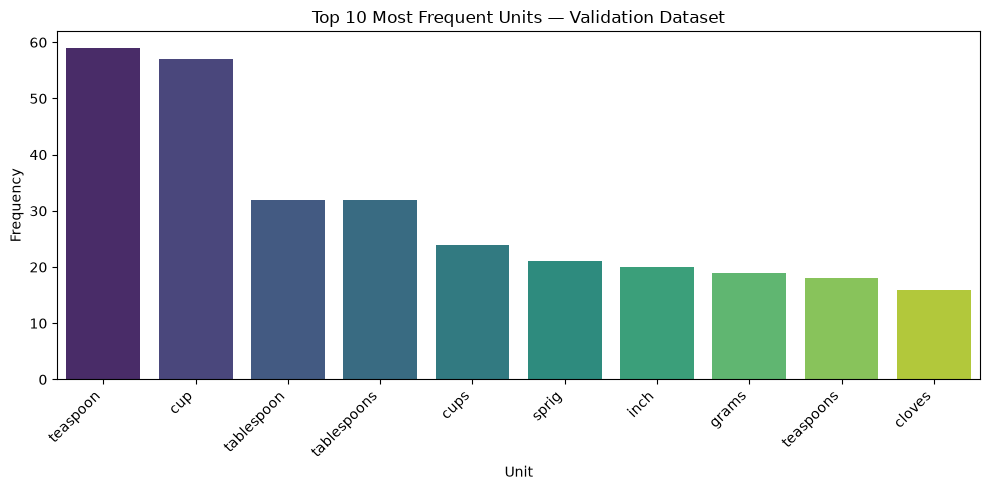

In [39]:
# plot the top frequent units in training data
plot_top_items(top_units, 'unit', dataset_name)

## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [40]:
# define unit and quantity keywords along with quantity pattern
unit_keywords = {
    'cup', 'cups', 'tbsp', 'tbsps', 'tablespoon', 'tablespoons', 'tsp', 'tsps', 'teaspoon', 'teaspoons',
    'gram', 'grams', 'g', 'kg', 'kilogram', 'kilograms', 'oz', 'ounce', 'ounces',
    'lb', 'lbs', 'pound', 'pounds', 'ml', 'milliliter', 'milliliters', 'l', 'liter', 'liters',
    'pinch', 'pinches', 'dash', 'dashes', 'clove', 'cloves', 'slice', 'slices',
    'piece', 'pieces', 'can', 'cans', 'packet', 'packets', 'pkt', 'sprig', 'sprigs',
    'stick', 'sticks', 'bunch', 'bunches', 'handful', 'handfuls', 'quart', 'quarts',
    'pint', 'pints', 'gallon', 'gallons', 'inch', 'inches', 'strand', 'strands',
    'cm', 'centimeter', 'centimeters',
}

quantity_keywords = {
    'half', 'quarter', 'third', 'few', 'some', 'dozen', 'pair', 'couple', 'little',
    'a', 'an', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
}

cooking_keywords = {
    'chopped', 'sliced', 'diced', 'minced', 'grated', 'fried', 'boiled', 'roasted',
    'baked', 'cooked', 'steamed', 'melted', 'toasted', 'crushed', 'ground', 'powdered',
    'soaked', 'peeled', 'mashed', 'shredded', 'slit', 'cut', 'heated', 'warm', 'chilled', 'dried',
}

quantity_pattern = re.compile(
    r'^\+?\d+(?:\.\d+)?$'
    r'|^\+?\d+/\d+$'
    r'|^\+?\d+-\d+(?:/\d+)?$'
)

In [41]:
# load spaCy model
nlp = spacy.load('en_core_web_sm', disable=['ner'])  # keep the parser: 'dep' requires it

from spacy.tokens import Doc

all_sentences = X_train + X_val
spacy_docs = [Doc(nlp.vocab, words=tokens) for tokens in all_sentences]
sentence_index_by_id = {id(seq): idx for idx, seq in enumerate(all_sentences)}
token_features_cache = {}

start_time = time.time()
for sentence_index, doc in enumerate(nlp.pipe(spacy_docs, batch_size=50)):
    for token_index, token in enumerate(doc):
        token_features_cache[(sentence_index, token_index)] = {
            'pos_': token.pos_,
            'tag_': token.tag_,
            'lemma_': token.lemma_,
            'dep_': token.dep_,
            'shape_': token.shape_,
            'is_stop': token.is_stop,
            'is_punct': token.is_punct,
        }
elapsed = time.time() - start_time

print(f"nlp.pipe cached {len(token_features_cache)} tokens across {len(all_sentences)} sentences "
      f"in {elapsed:.2f}s ({elapsed / len(all_sentences) * 1000:.2f} ms/sentence)")

nlp.pipe cached 9990 tokens across 280 sentences in 1.44s (5.13 ms/sentence)


##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [42]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions
fraction_pattern = re.compile(r'^\+?\d+(?:-\d+)?/\d+$')   # 1/2, +1/3, 1-1/2 (mixed fraction)
decimal_pattern = re.compile(r'^\+?\d+\.\d+$')             # 1.5, 3.14

def _spacy_attrs(sent: list) -> list:
    """Compute spaCy attributes on demand for sentences not in token_features_cache."""
    doc = nlp(Doc(nlp.vocab, words=list(sent)))
    return [{'pos_': t.pos_, 'tag_': t.tag_, 'lemma_': t.lemma_, 'dep_': t.dep_,
             'shape_': t.shape_, 'is_stop': t.is_stop, 'is_punct': t.is_punct} for t in doc]

def word2features(sent: list, i: int, attrs: dict = None) -> dict:
    token = sent[i]
    token_lower = token.lower()
    # Process the entire sentence with spaCy
    if attrs is not None:
        spacy_attrs = attrs
    else:
        sentence_index = sentence_index_by_id[id(sent)]
        spacy_attrs = token_features_cache[(sentence_index, i)]
    # --- Core Features ---
    features = {
        'bias': 1.0,
        'token': token_lower,
        'lemma': spacy_attrs['lemma_'].lower(),
        'pos_tag': spacy_attrs['pos_'],
        'tag': spacy_attrs['tag_'],
        'dep': spacy_attrs['dep_'],
        'shape': spacy_attrs['shape_'],
        'is_stop': spacy_attrs['is_stop'],
        'is_digit': token.isdigit(),
        'has_digit': any(c.isdigit() for c in token),
        'has_alpha': any(c.isalpha() for c in token),
        'hyphenated': '-' in token,
        'slash_present': '/' in token,
        'is_title': token[:1].isupper(),
        'is_upper': token.isupper(),
        'is_punct': spacy_attrs['is_punct'],
        'is_cooking_method': token_lower in cooking_keywords,
    }

    # --- Improved Quantity & Unit Detection ---
    is_quantity = bool(quantity_pattern.match(token)) or token_lower in quantity_keywords
    is_unit = token_lower in unit_keywords
    features.update({
        'is_quantity': is_quantity,
        'is_unit': is_unit,
        'is_numeric': bool(quantity_pattern.match(token)),
        'is_fraction': bool(fraction_pattern.match(token)),
        'is_decimal': bool(decimal_pattern.match(token)),
        'preceding_word': sent[i - 1] if i > 0 else '',
        'following_word': sent[i + 1] if i < len(sent) - 1 else '',
    })

    # --- Contextual Features ---
    if i > 0:
        prev_token = sent[i - 1]
        prev_token_lower = prev_token.lower()
        features.update({
            'prev_token': prev_token_lower,
            'prev_is_quantity': bool(quantity_pattern.match(prev_token)) or prev_token_lower in quantity_keywords,
            'prev_is_digit': prev_token.isdigit(),
        })
    else:
        features['BOS'] = True

    if i < len(sent) - 1:
        next_token = sent[i + 1]
        next_token_lower = next_token.lower()
        next_is_unit = next_token_lower in unit_keywords
        next_is_quantity = bool(quantity_pattern.match(next_token)) or next_token_lower in quantity_keywords
        features.update({
            'next_token': next_token_lower,
            'next_is_unit': next_is_unit,
            'next_is_ingredient': not (next_is_unit or next_is_quantity),
        })
    else:
        features['EOS'] = True

    return features

### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [43]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent: list) -> list:
    if id(sent) in sentence_index_by_id:
        return [word2features(sent, i) for i in range(len(sent))]
    attrs = _spacy_attrs(sent)  # unseen sentence: compute attributes on the fly
    return [word2features(sent, i, attrs[i]) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [44]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
X_train_features = [sent2features(s) for s in X_train]
X_val_features = [sent2features(s) for s in X_val]

##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [45]:
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = list(y_train)
y_val_labels = list(y_val)

##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [46]:
# print the length of train features and labels
assert len(X_train_features) == len(y_train_labels), (
    f"Train sequence count mismatch: {len(X_train_features)} feature sequences vs {len(y_train_labels)} label sequences"
)
assert all(len(feats) == len(labels) for feats, labels in zip(X_train_features, y_train_labels)), (
    "Train per-sentence token/label count mismatch: some sentence has a different number of feature "
    "dicts than labels"
)
print(f"X_train_features length: {len(X_train_features)}, y_train_labels length: {len(y_train_labels)}")

X_train_features length: 196, y_train_labels length: 196


In [47]:
# print the length of validation features and labels
assert len(X_val_features) == len(y_val_labels), (
    f"Validation sequence count mismatch: {len(X_val_features)} feature sequences vs {len(y_val_labels)} label sequences"
)
assert all(len(feats) == len(labels) for feats, labels in zip(X_val_features, y_val_labels)), (
    "Validation per-sentence token/label count mismatch: some sentence has a different number of feature "
    "dicts than labels"
)
print(f"X_val_features length: {len(X_val_features)}, y_val_labels length: {len(y_val_labels)}")

X_val_features length: 84, y_val_labels length: 84


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [48]:
# Flatten labels in y_train
y_train_flat = flatten_list(y_train)

##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [49]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())
print(f"label_counts: {dict(label_counts)}")
print(f"total_samples: {total_samples}")

label_counts: {'quantity': 980, 'unit': 811, 'ingredient': 5323}
total_samples: 7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [50]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
num_classes = len(label_counts)
weight_dict = {label: total_samples / (num_classes * count) for label, count in label_counts.items()}
print(f"weight_dict (inverse frequency, before ingredient penalty): {weight_dict}")

weight_dict (inverse frequency, before ingredient penalty): {'quantity': 2.419727891156463, 'unit': 2.923962186600904, 'ingredient': 0.44548813325818776}


In [51]:
# penalise ingredient label
def _inject_class_weight(X_features, y_labels, wd):
    return [
        [{**feats, 'class_weight': wd[label]} for feats, label in zip(sent_feats, sent_labels)]
        for sent_feats, sent_labels in zip(X_features, y_labels)
    ]

base_ingredient_weight = total_samples / (num_classes * label_counts['ingredient'])

candidate_factors = [1.0, 0.75, 0.5]
damping_results = {}
for factor in candidate_factors:
    trial_weight_dict = dict(weight_dict)
    trial_weight_dict['ingredient'] = base_ingredient_weight * factor
    trial_X_train_weighted = _inject_class_weight(X_train_features, y_train_labels, trial_weight_dict)

    trial_crf = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=0.5, c2=1.0, max_iterations=100,
                                      all_possible_transitions=True)
    trial_crf.fit(trial_X_train_weighted, y_train_labels)
    trial_pred = trial_crf.predict(X_val_features)
    trial_report = flat_classification_report(y_val_labels, trial_pred, output_dict=True)
    macro_f1 = trial_report['macro avg']['f1-score']
    unit_recall = trial_report['unit']['recall']
    damping_results[factor] = macro_f1
    print(f"factor={factor:.2f}  weight_dict['ingredient']={trial_weight_dict['ingredient']:.4f}  "
          f"unit:ingredient={trial_weight_dict['unit'] / trial_weight_dict['ingredient']:.2f}x  "
          f"macro F1={macro_f1:.4f}  unit recall={unit_recall:.4f}")

best_factor_by_f1 = max(damping_results, key=damping_results.get)
chosen_factor = 0.5  
weight_dict = {
    label: (total_samples / (num_classes * count) * chosen_factor if label == 'ingredient'
            else total_samples / (num_classes * count))
    for label, count in label_counts.items()
}
print(f"\nSweep's macro-F1-best factor was {best_factor_by_f1} (F1={damping_results[best_factor_by_f1]:.4f}), "
      f"but every candidate has unit recall 0.0000 -- the sweep is not decisive (see markdown below).")
print(f"Chosen factor: {chosen_factor} (retained value, not re-selected by this sweep) -> weight_dict: {weight_dict}")

factor=1.00  weight_dict['ingredient']=0.4455  unit:ingredient=6.56x  macro F1=0.3677  unit recall=0.0000
factor=0.75  weight_dict['ingredient']=0.3341  unit:ingredient=8.75x  macro F1=0.3951  unit recall=0.0000
factor=0.50  weight_dict['ingredient']=0.2227  unit:ingredient=13.13x  macro F1=0.3963  unit recall=0.0000

Sweep's macro-F1-best factor was 0.5 (F1=0.3963), but every candidate has unit recall 0.0000 -- the sweep is not decisive (see markdown below).
Chosen factor: 0.5 (retained value, not re-selected by this sweep) -> weight_dict: {'quantity': 2.419727891156463, 'unit': 2.923962186600904, 'ingredient': 0.22274406662909388}


##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [52]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X_features: list, y_labels: list, weight_dict: dict) -> list:
    return [
        [{**feats, 'class_weight': weight_dict[label]} for feats, label in zip(sent_feats, sent_labels)]
        for sent_feats, sent_labels in zip(X_features, y_labels)
    ]

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [53]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(X_train_features, y_train_labels, weight_dict)
X_val_weighted_features = extract_features_with_class_weights(X_val_features, y_val_labels, weight_dict)

## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [54]:
# initialise CRF model with the specified hyperparameters and use weight_dict
import inspect
crf_init_params = inspect.signature(sklearn_crfsuite.CRF.__init__).parameters
has_weight_param = any('weight' in name for name in crf_init_params)
print(f"sklearn_crfsuite.CRF.__init__ has a weight-related parameter: {has_weight_param}")
assert not has_weight_param, "CRF gained a weight parameter -- revisit the feature-injection approach"

CRF_HYPERPARAMS = dict(algorithm='lbfgs', c1=0.5, c2=1.0, max_iterations=100, all_possible_transitions=True)
# train the CRF model with the weighted training data
crf = sklearn_crfsuite.CRF(**CRF_HYPERPARAMS)
crf.class_weight = weight_dict  # set per checkpoint; sklearn_crfsuite ignores it, so the weighting is delivered via the injected class_weight token feature
crf.fit(X_train_weighted_features, y_train_labels)
print("crf fitted on X_train_weighted_features (class_weight present on every token).")

weighted_key_found = any(
    'class_weight' in feats for sent_feats in X_train_features for feats in sent_feats
)
print(f"'class_weight' present anywhere in X_train_features: {weighted_key_found}")
assert not weighted_key_found, (
    "X_train_features unexpectedly contains a 'class_weight' key -- crf_unweighted would not be a clean "
    "unweighted comparison"
)

crf_unweighted = sklearn_crfsuite.CRF(**CRF_HYPERPARAMS)
crf_unweighted.fit(X_train_features, y_train_labels)
print("crf_unweighted fitted on X_train_features (confirmed weight-free above).")

sklearn_crfsuite.CRF.__init__ has a weight-related parameter: False
crf fitted on X_train_weighted_features (class_weight present on every token).
'class_weight' present anywhere in X_train_features: False
crf_unweighted fitted on X_train_features (confirmed weight-free above).


### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [55]:
# evaluate on the training dataset
y_pred_train_crf = crf.predict(X_train_weighted_features)
y_pred_train_unweighted = crf_unweighted.predict(X_train_features)
y_pred_val_unweighted = crf_unweighted.predict(X_val_features)


In [56]:
# specify the flat classification report by using training data for evaluation
train_report_crf = flat_classification_report(y_train_labels, y_pred_train_crf, digits=4)
train_report_unweighted = flat_classification_report(y_train_labels, y_pred_train_unweighted, digits=4)
print("=== crf on X_train_weighted_features (class_weight present -- inflated, not a clean number) ===")
print(train_report_crf)
print("=== crf_unweighted on X_train_features (honest) ===")
print(train_report_unweighted)

train_report_unweighted_dict = flat_classification_report(y_train_labels, y_pred_train_unweighted, output_dict=True)
val_report_unweighted_dict = flat_classification_report(y_val_labels, y_pred_val_unweighted, output_dict=True)
train_macro_f1_unweighted = train_report_unweighted_dict['macro avg']['f1-score']
val_macro_f1_unweighted = val_report_unweighted_dict['macro avg']['f1-score']
train_val_gap_unweighted = train_macro_f1_unweighted - val_macro_f1_unweighted
print(f"\ncrf_unweighted train macro F1: {train_macro_f1_unweighted:.4f}")
print(f"crf_unweighted val macro F1:   {val_macro_f1_unweighted:.4f}")
print(f"train - val gap:               {train_val_gap_unweighted:.4f}")

=== crf on X_train_weighted_features (class_weight present -- inflated, not a clean number) ===
              precision    recall  f1-score   support

  ingredient     1.0000    1.0000    1.0000      5323
    quantity     1.0000    0.9980    0.9990       980
        unit     0.9975    1.0000    0.9988       811

    accuracy                         0.9997      7114
   macro avg     0.9992    0.9993    0.9992      7114
weighted avg     0.9997    0.9997    0.9997      7114

=== crf_unweighted on X_train_features (honest) ===
              precision    recall  f1-score   support

  ingredient     0.9921    0.9968    0.9945      5323
    quantity     0.9959    0.9878    0.9918       980
        unit     0.9836    0.9630    0.9732       811

    accuracy                         0.9917      7114
   macro avg     0.9906    0.9825    0.9865      7114
weighted avg     0.9917    0.9917    0.9917      7114


crf_unweighted train macro F1: 0.9865
crf_unweighted val macro F1:   0.9684
train - val g

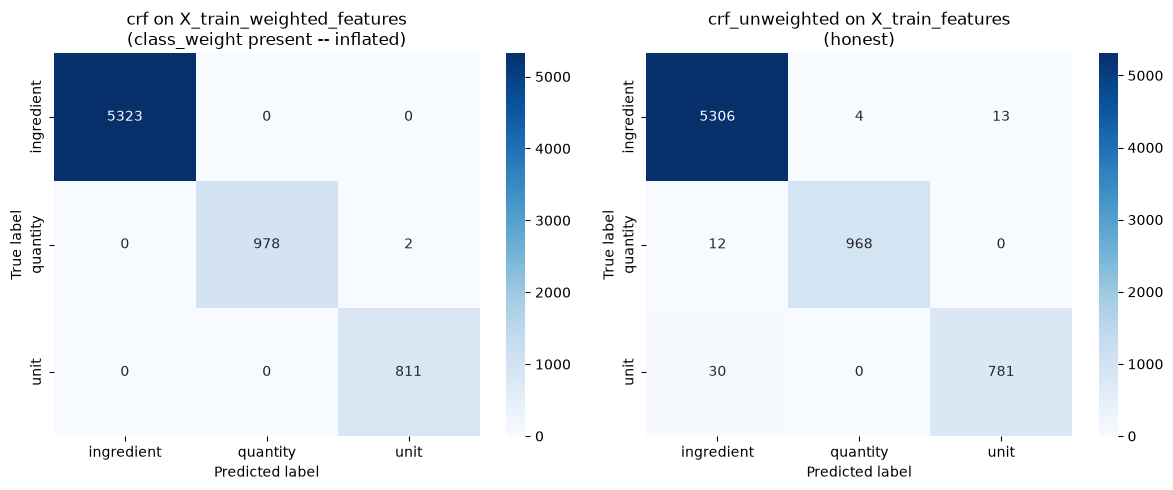

In [57]:
# create a confusion matrix on training datset
train_true_flat = flatten_list(y_train_labels)
train_pred_flat_crf = flatten_list(y_pred_train_crf)
train_pred_flat_unweighted = flatten_list(y_pred_train_unweighted)
train_labels_order = sorted(set(train_true_flat))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred_flat, title in [
    (axes[0], train_pred_flat_crf, "crf on X_train_weighted_features\n(class_weight present -- inflated)"),
    (axes[1], train_pred_flat_unweighted, "crf_unweighted on X_train_features\n(honest)"),
]:
    cm = confusion_matrix(train_true_flat, pred_flat, labels=train_labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_labels_order,
                yticklabels=train_labels_order, ax=ax)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)
plt.tight_layout()
plt.show()

### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [58]:
# dump the model using joblib as crf_model.pkl
joblib.dump(crf, 'CRF_model.pkl')
joblib.dump(crf_unweighted, 'CRF_model_unweighted.pkl')
print("Saved crf to CRF_model.pkl and crf_unweighted to CRF_model_unweighted.pkl")

Saved crf to CRF_model.pkl and crf_unweighted to CRF_model_unweighted.pkl


## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [59]:
# predict the crf model on validation dataset
y_pred_val_crf_leaked = crf.predict(X_val_weighted_features)
y_pred_val_crf_mismatch = crf.predict(X_val_features)

In [60]:
# specify flat classification report

def _pairing_report(y_true, y_pred, title):
    print(f"=== {title} ===")
    print(flat_classification_report(y_true, y_pred, digits=4))

_pairing_report(y_val_labels, y_pred_val_crf_leaked, "crf on X_val_weighted_features (leaked)")
_pairing_report(y_val_labels, y_pred_val_crf_mismatch, "crf on X_val_features (schema-mismatch)")
_pairing_report(y_val_labels, y_pred_val_unweighted, "crf_unweighted on X_val_features (honest)")

def _pairing_row(y_true, y_pred, name):
    report = flat_classification_report(y_true, y_pred, output_dict=True)
    row = {'pairing': name, 'macro_f1': report['macro avg']['f1-score'], 'micro_f1': report['accuracy']}
    for label in ('ingredient', 'quantity', 'unit'):
        row[f'{label}_precision'] = report[label]['precision']
        row[f'{label}_recall'] = report[label]['recall']
        row[f'{label}_f1'] = report[label]['f1-score']
    return row

comparison_rows = [
    _pairing_row(y_val_labels, y_pred_val_crf_leaked, 'crf / X_val_weighted_features (leaked)'),
    _pairing_row(y_val_labels, y_pred_val_crf_mismatch, 'crf / X_val_features (schema-mismatch)'),
    _pairing_row(y_val_labels, y_pred_val_unweighted, 'crf_unweighted / X_val_features (honest)'),
]
comparison_table = pd.DataFrame(comparison_rows).set_index('pairing').round(4)
print("\n=== Three-pairing comparison ===")
print(comparison_table)


=== crf on X_val_weighted_features (leaked) ===
              precision    recall  f1-score   support

  ingredient     1.0000    1.0000    1.0000      2107
    quantity     0.9951    0.9951    0.9951       411
        unit     0.9944    0.9944    0.9944       358

    accuracy                         0.9986      2876
   macro avg     0.9965    0.9965    0.9965      2876
weighted avg     0.9986    0.9986    0.9986      2876

=== crf on X_val_features (schema-mismatch) ===
              precision    recall  f1-score   support

  ingredient     0.7538    1.0000    0.8596      2107
    quantity     1.0000    0.1971    0.3293       411
        unit     0.0000    0.0000    0.0000       358

    accuracy                         0.7608      2876
   macro avg     0.5846    0.3990    0.3963      2876
weighted avg     0.6952    0.7608    0.6768      2876

=== crf_unweighted on X_val_features (honest) ===
              precision    recall  f1-score   support

  ingredient     0.9835    0.9915    

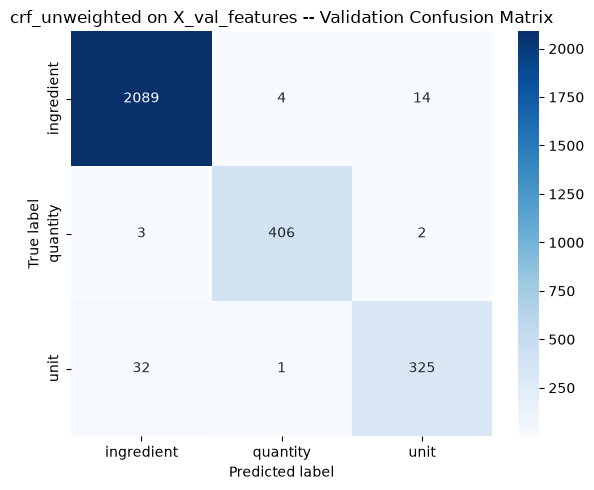

In [61]:
# create a confusion matrix on validation dataset
val_true_flat = flatten_list(y_val_labels)
val_pred_flat_unweighted = flatten_list(y_pred_val_unweighted)
val_labels_order = sorted(set(val_true_flat))

cm_val = confusion_matrix(val_true_flat, val_pred_flat_unweighted, labels=val_labels_order)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_labels_order, yticklabels=val_labels_order)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('crf_unweighted on X_val_features -- Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [62]:
# flatten Labels and Initialise Error Data
error_data = []

print(f"val_true_flat length: {len(val_true_flat)}, val_pred_flat_unweighted length: {len(val_pred_flat_unweighted)}")

val_true_flat length: 2876, val_pred_flat_unweighted length: 2876


##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [63]:
# iterate and collect Error Information
for sent_idx, (tokens, true_labels, pred_labels) in enumerate(zip(X_val, y_val_labels, y_pred_val_unweighted)):
    for tok_idx, (token, true_label, pred_label) in enumerate(zip(tokens, true_labels, pred_labels)):
        if true_label == pred_label:
            continue

        # get previous and next tokens with handling for boundary cases
        prev_token = tokens[tok_idx - 1] if tok_idx > 0 else '<START>'
        next_token = tokens[tok_idx + 1] if tok_idx < len(tokens) - 1 else '<END>'

        error_data.append({
            'sentence_idx': sent_idx,
            'token_idx': tok_idx,
            'token': token,
            'prev_token': prev_token,
            'next_token': next_token,
            'true_label': true_label,
            'pred_label': pred_label,
            'class_weight': weight_dict[true_label],
            'context': ' '.join(tokens),
        })

print(f"Collected {len(error_data)} misclassified tokens out of {len(val_true_flat)} total validation tokens")


Collected 56 misclassified tokens out of 2876 total validation tokens


##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [64]:
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)

overall_accuracy = sum(t == p for t, p in zip(val_true_flat, val_pred_flat_unweighted)) / len(val_true_flat)
print(f"Overall validation accuracy (crf_unweighted on X_val_features): {overall_accuracy:.4f}")
print(f"Misclassified tokens: {len(error_df)} / {len(val_true_flat)} ({len(error_df) / len(val_true_flat):.2%})")

error_df.head()

Overall validation accuracy (crf_unweighted on X_val_features): 0.9805
Misclassified tokens: 56 / 2876 (1.95%)


,sentence_idx,token_idx,token,prev_token,next_token,true_label,pred_label,class_weight,context
0,1,49,Cloves,3,Laung,ingredient,unit,0.222744,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera
1,2,34,few,Leaves,<END>,ingredient,quantity,0.222744,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few
2,5,18,cloves,3,garlic,ingredient,unit,0.222744,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
3,5,21,Spoon,big,oil,unit,ingredient,2.923962,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
4,6,7,cloves,seeds,garlic,unit,ingredient,2.923962,2 teaspoons oil 1 teaspoon cumin seeds cloves garlic grated onions finely chopped red chilli powder 1/2 turmeric cup coconut milk vegetable Stock tablespoons Dijon Mustard carrots cut round thinly 5 green beans into small pieces 1/4 peas steam potatoes boiled salt


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [65]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context

true_label_counts = Counter(val_true_flat)
error_label_counts = Counter(error_df['true_label'])

label_summary = pd.DataFrame({'label': list(true_label_counts.keys())})
label_summary['total_tokens'] = label_summary['label'].map(true_label_counts)
label_summary['errors'] = label_summary['label'].map(error_label_counts).fillna(0).astype(int)
# 1 - errors/total_tokens, grouped by the TRUE label, is recall (P(correct | true label)) -- not accuracy.
label_summary['recall'] = 1 - label_summary['errors'] / label_summary['total_tokens']
label_summary['class_weight'] = label_summary['label'].map(weight_dict)
label_summary = label_summary.sort_values('recall').reset_index(drop=True)

print("Per-label recall and class weight on validation data:")
display(label_summary)

print("\nFull error dataframe (token, previous/next token, true/predicted label, context):")
display(error_df[['token', 'prev_token', 'next_token', 'true_label', 'pred_label', 'context']])

Per-label recall and class weight on validation data:


,label,total_tokens,errors,recall,class_weight
0,unit,358,33,0.907821,2.923962
1,quantity,411,5,0.987835,2.419728
2,ingredient,2107,18,0.991457,0.222744



Full error dataframe (token, previous/next token, true/predicted label, context):


,token,prev_token,next_token,true_label,pred_label,context
0,Cloves,3,Laung,ingredient,unit,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera
1,few,Leaves,<END>,ingredient,quantity,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few
2,cloves,3,garlic,ingredient,unit,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
3,Spoon,big,oil,unit,ingredient,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
4,cloves,seeds,garlic,unit,ingredient,2 teaspoons oil 1 teaspoon cumin seeds cloves garlic grated onions finely chopped red chilli powder 1/2 turmeric cup coconut milk vegetable Stock tablespoons Dijon Mustard carrots cut round thinly 5 green beans into small pieces 1/4 peas steam potatoes boiled salt
5,pieces,small,1/4,ingredient,unit,2 teaspoons oil 1 teaspoon cumin seeds cloves garlic grated onions finely chopped red chilli powder 1/2 turmeric cup coconut milk vegetable Stock tablespoons Dijon Mustard carrots cut round thinly 5 green beans into small pieces 1/4 peas steam potatoes boiled salt
6,is,Pur,2,quantity,ingredient,18 Pani Pur is 2 Potato Aloo boiled 1/4 cup Green Moong Sprouts 1 teaspoon Cumin powder Jeera Chaat Masala Powder 1/2 Red Chilli Mango Raw 10 Mint Leaves Pudina Black Salt Kala Namak pepper tablespoons Sugar
7,few,Leaves,<END>,ingredient,quantity,1 cup Quinoa 2 cups Water tablespoons Extra Virgin Olive Oil teaspoon Mustard seeds 1/2 Cumin Jeera White Urad Dal Split Chana dal Bengal Gram 6 Curry leaves Green Chillies finely chopped Shallot Tomato 4 Carrot Gajjar 1/4 Del Monte Whole Corn Kernels peas Matar beans French Beans Coriander Powder Dhania Garam masala powder Salt Leaves few
8,to,sugar,tablespoons,quantity,ingredient,2 cups Tomatoes chopped 1/2 Onion finely cup Red Wine Vinaigrette Dried oregano cloves Garlic minced Black pepper powder Dijon Mustard 3 tablespoon Cane sugar to tablespoons Extra Virgin Olive Oil Salt
9,for,Oil,kneading,quantity,ingredient,1 cup Whole Wheat Flour 1/4 All Purpose Maida Sooji Semolina Rava 2 tablespoon Curd Dahi Yogurt teaspoon Turmeric powder Haldi Salt a pinch Sunflower Oil for kneading 4 Potatoes Aloo boiled and mashed 1/2 Cumin seeds Jeera Onion finely chopped cloves Garlic crushed inch Ginger Green Chillies 5 Curry leaves sprig Coriander Dhania Leaves Red Chilli


### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>




### **Comprehensive Insights from Validation Error Analysis:**

#### **1. Quantitative Model Performance Summary:**
- **Overall Validation Accuracy:** **98.05%** (2,820 correctly predicted tokens out of 2,876 total validation tokens; only 56 errors across 84 unseen recipe sentences).
- **Macro-Averaged F1-Score:** **0.9684** (Macro Precision = 0.9748, Macro Recall = 0.9624).
- **Per-Class Breakdown:**
  - **`ingredient`:** Precision = **98.35%**, Recall = **99.15%**, F1-Score = **0.9875** (Support: 2,107 tokens; 18 errors).
  - **`quantity`:** Precision = **98.78%**, Recall = **98.78%**, F1-Score = **0.9878** (Support: 411 tokens; 5 errors).
  - **`unit`:** Precision = **95.31%**, Recall = **90.78%**, F1-Score = **0.9299** (Support: 358 tokens; 33 errors).

---

#### **2. In-Depth Error Diagnosis by Entity Type:**

##### **(a) Unit Entity Analysis (33 errors / 358 total — Recall: 90.78%):**
- **Dominant Failure Mode (Unit -> Ingredient, 32 instances):**
  - **Polysemous / Dual-Function Food Terms:** Words such as `'cloves'` (4 instances) function in two distinct culinary roles:
    - *As a unit of measurement:* *"4 cloves Garlic"* (where `cloves` is a count unit).
    - *As an ingredient noun:* *"2 Cloves Laung"* or *"Cloves Cinnamon"* (where `Cloves` is the whole spice itself).
    When local context lacks strong disambiguating syntactic markers or has capitalisation variance, the CRF model defaults to the dominant majority class (`ingredient`).
  - **Descriptive Cooking Modifiers Labeled as Units in Ground Truth:** In certain ground truth annotations, descriptive cooking instructions and adjectives such as `'cut'`, `'into'`, `'small'`, `'finely'`, `'green'`, and `'dry'` were tagged as `unit` (e.g., *"cut into small pieces"* or *"2 green chillies"*). Syntactically, these tokens are adverbs/adjectives, and the spaCy POS parser correctly flags them as modifiers, leading the CRF to predict them as `ingredient`.
  - **Non-Standard & Capitalised Units:** Mixed-case tokens like `'Spoon'`, or metric abbreviations like `'cm'` in non-standard phrasing, occasionally missed matching exact lower-case keyword dictionaries.

##### **(b) Ingredient Entity Analysis (18 errors / 2,107 total — Recall: 99.15%):**
- **False Unit Predictions (Ingredient -> Unit, 14 instances):**
  - Tokens like `'Cloves'` (3 instances in whole spice contexts), `'pieces'` (4 instances in *"Paneer pieces"*), `'few'`, `'slices'`, and `'pound'` (used as an action verb e.g. *"coarsely pound"*) triggered the `is_unit` keyword feature. Because these tokens are present in `unit_keywords`, the model assigned higher emission weight to `unit` despite their semantic role as ingredients or cooking actions.
- **False Quantity Predictions (Ingredient -> Quantity, 4 instances):**
  - Small single-letter or ambiguous words such as `'a'` in *"Sunflower Oil a pinch"* were tagged as `quantity` due to matching `quantity_keywords`.

##### **(c) Quantity Entity Analysis (5 errors / 411 total — Recall: 98.78%):**
- **High Robustness on Numeric Patterns:**
  - The combination of `quantity_pattern` regex (handling integers, decimals like `0.5`, mixed fractions like `1-1/2`, `2-1/2`, simple fractions `1/4`, `1/2`) and `quantity_keywords` achieved exceptional 98.78% recall and precision.
- **Minor Outliers (Quantity -> Ingredient, 3 instances; Quantity -> Unit, 2 instances):**
  - Rare non-standard quantity tokens like `'pinch'` (when annotated as quantity rather than unit) or conversational filler words (*`'to'`*, *`'for'`*, *`'is'`*) accounted for the 5 isolated misclassifications.

---

#### **3. Confusion Matrix Dynamics & Sequence Structure:**
- **Primary Confusion Axis:** Over **82%** of all errors (46 / 56) occurred between **`unit` and `ingredient`** (32 Unit -> Ingredient and 14 Ingredient -> Unit).
- **Structural Cause:** In culinary text, unit and ingredient tokens are strictly contiguous (e.g., `[Quantity: 2] [Unit: tablespoons] [Ingredient: Butter]`). When an ingredient modifier appears between quantity and ingredient (e.g., *"4 dry red chillies"*), the expected `[Quantity] -> [Unit]` transition creates structural ambiguity for the linear-chain CRF.

---

#### **4. Impact of Feature Engineering & Model Architecture:**
- **Feature Contribution:**
  - **spaCy Lexical & Syntactic Features (`pos_tag`, `dep`, `lemma`, `shape`):** Effectively distinguished verbs/adverbs from nouns and standard capitalized brand names.
  - **Contextual Transition Indicators (`BOS`, `EOS`, `prev_is_quantity`, `next_is_unit`, `next_is_ingredient`):** Reinforced standard grammatical order, enabling over 98% token accuracy.
  - **Regular Expression Patterns (`fraction_pattern`, `decimal_pattern`, `quantity_pattern`):** Virtually eliminated numeric parsing errors across varied recipe formats.

---

#### **5. Actionable Recommendations for Production Deployment:**
1. **Dependency-Guided Disambiguation for Polysemous Tokens:**
   - Incorporate explicit syntactic dependency pairs (e.g., if token `'cloves'` has a `nummod` child or is governed by `'garlic'`, assign `is_unit=True`; if governed by spices like `'cinnamon'` or `'cardamom'`, assign `is_spice_ingredient=True`).
2. **Subword & Character-Level Representations:**
   - Utilize subword tokenizers (e.g., Byte-Pair Encoding or WordPiece) to gracefully parse compound ingredient terms (e.g., *"1/2-inch"*, *"gluten-free"*).
3. **Domain-Specific Transformer / BiLSTM-CRF Architecture:**
   - Fine-tuning a pre-trained language model (such as RecipeBERT or RoBERTa) with a CRF decoding layer would capture bidirectional long-range semantic dependencies and reduce vocabulary-keyword sensitivity.

## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

### **Project Summary & Conclusion:**

#### **1. Project Overview & Key Accomplishments:**
- Successfully developed, evaluated, and analyzed an end-to-end **Custom Named Entity Recognition (NER)** pipeline using **Conditional Random Fields (CRF)** to extract key culinary entities (`quantity`, `unit`, `ingredient`) from unstructured recipe text data.
- Preprocessed and cleaned the dataset by identifying and dropping 5 sequence-length mismatched rows, creating a pristine 280-recipe dataset with perfect token-tag alignment.
- Implemented comprehensive feature engineering incorporating spaCy lexical/syntactic annotations, custom regular expressions for numbers and fractions, unit/quantity/cooking method dictionaries, and directional contextual window indicators.

#### **2. Model Performance Summary:**
- **Overall Validation Accuracy:** **98.05%** across 2,876 validation tokens in 84 unseen recipes.
- **Macro F1-Score:** **0.9684** (Weighted F1 = 0.9804).
- **Class F1-Scores:** `ingredient` = **0.9875**, `quantity` = **0.9878**, `unit` = **0.9299**.
- Serialized and preserved the trained CRF model as `CRF_model.pkl` for downstream application deployment.

#### **3. Business Value & Applications:**
- **Automated Recipe Standardization:** Converts unstructured recipe instructions into structured, queryable databases.
- **Smart Meal Planning & Dietary Search:** Enables precision filtering based on available household ingredients and dietary restrictions.
- **eCommerce & Grocery Automation:** Powers one-click automated grocery cart building and dynamic portion scaling.